In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Tesla - Experimentation ML") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 3.3.0


In [6]:
from pyspark.sql.functions import to_date, col

df = spark.read.csv("hdfs://namenode:9000/data/tesla/raw/tesla.csv", header=True, inferSchema=True)
df = df.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))
df = df.orderBy("Date").dropDuplicates(["Date"])

print("Lignes totales :", df.count())
print("Période couverte :")
df.selectExpr("min(Date) as debut", "max(Date) as fin").show()

Lignes totales : 3562
Période couverte :
+----------+----------+
|     debut|       fin|
+----------+----------+
|2010-06-29|2024-08-22|
+----------+----------+



In [7]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, abs as spark_abs, mean as spark_mean, stddev as spark_stddev, lit

w = Window.orderBy("Date")

df_ret = df.withColumn("Return", (col("Close") - lag("Close", 1).over(w)) / lag("Close", 1).over(w))

stats_ret = df_ret.select(
    spark_mean("Return").alias("mean_ret"),
    spark_stddev("Return").alias("std_ret")
).collect()[0]

mean_ret, std_ret = stats_ret["mean_ret"], stats_ret["std_ret"]
print(f"Rendement moyen quotidien : {mean_ret:.5f}")
print(f"Ecart-type quotidien : {std_ret:.5f}")

df_ret = df_ret.withColumn("z_score", (col("Return") - lit(mean_ret)) / lit(std_ret))
df_ret = df_ret.withColumn("is_outlier", spark_abs(col("z_score")) > 3)

nb_outliers = df_ret.filter(col("is_outlier")).count()
print(f"\nNombre de jours aberrants détectés (|z-score| > 3) : {nb_outliers}")
df_ret.filter(col("is_outlier")).select("Date", "Close", "Return", "z_score").orderBy(spark_abs(col("z_score")).desc()).show(10)

Rendement moyen quotidien : 0.00201
Ecart-type quotidien : 0.03589

Nombre de jours aberrants détectés (|z-score| > 3) : 61
+----------+----------+--------------------+------------------+
|      Date|     Close|              Return|           z_score|
+----------+----------+--------------------+------------------+
|2013-05-09|  4.626667| 0.24395072987549127| 6.741845896924955|
|2020-09-08|    110.07|-0.21062823851651982|-5.925480199025753|
|2020-02-03|      52.0| 0.19894859586288038| 5.487813602892772|
|2012-01-13|  1.519333|-0.19327437049103896|-5.441896222225295|
|2021-03-09|224.526672|  0.1964120725708824|5.4171306854595915|
|2010-11-10|  1.957333| 0.19204202192448241|   5.2953545795619|
|2020-03-16| 29.671333|-0.18577807826683834|-5.233004072088246|
|2020-03-19| 28.509333| 0.18387686429152408| 5.067823783917326|
|2019-10-24| 19.978666| 0.17669232671165097|4.8676190082877095|
|2020-02-05|     48.98| -0.1717583882249137|-4.842330508475281|
+----------+----------+--------------------+

In [8]:
from pyspark.sql.functions import avg, stddev, lead

def build_features(spark_df, horizon=1):
    """
    Construit les features techniques (Spark Window functions) et la cible
    Target = Close à horizon jours dans le futur (1 = lendemain, 5 = +1 semaine, 20 = +1 mois)
    """
    w_ord = Window.orderBy("Date")
    w5  = Window.orderBy("Date").rowsBetween(-4, 0)
    w10 = Window.orderBy("Date").rowsBetween(-9, 0)
    w20 = Window.orderBy("Date").rowsBetween(-19, 0)

    out = spark_df \
        .withColumn("MA5",  avg("Close").over(w5)) \
        .withColumn("MA10", avg("Close").over(w10)) \
        .withColumn("MA20", avg("Close").over(w20)) \
        .withColumn("Volatility10", stddev("Close").over(w10)) \
        .withColumn("Close_lag1", lag("Close", 1).over(w_ord)) \
        .withColumn("Close_lag2", lag("Close", 2).over(w_ord)) \
        .withColumn("Close_lag3", lag("Close", 3).over(w_ord)) \
        .withColumn("Close_lag5", lag("Close", 5).over(w_ord)) \
        .withColumn("Range", col("High") - col("Low")) \
        .withColumn("Return", (col("Close") - lag("Close", 1).over(w_ord)) / lag("Close", 1).over(w_ord)) \
        .withColumn("Target", lead("Close", horizon).over(w_ord))

    return out.dropna()

print("Fonction build_features prête.")

Fonction build_features prête.


In [9]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import row_number
import numpy as np

FEATURES = ["Open","High","Low","Volume","MA5","MA10","MA20",
            "Volatility10","Close_lag1","Close_lag2","Close_lag3","Close_lag5",
            "Return","Range"]

def run_experiment(spark_df, label="experiment"):
    """
    Prend un DataFrame Spark deja feature-engineered (avec colonne Target),
    entraine 3 modeles Spark MLlib avec split temporel 80/20,
    retourne (liste de metriques, dict de predictions pandas par modele).
    """
    assembler = VectorAssembler(inputCols=FEATURES, outputCol="features_raw")
    assembled = assembler.transform(spark_df)

    scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)
    scaled = scaler.fit(assembled).transform(assembled)

    w_ord = Window.orderBy("Date")
    indexed = scaled.withColumn("row_idx", row_number().over(w_ord))
    total = indexed.count()
    split_idx = int(total * 0.8)

    train_df = indexed.filter(col("row_idx") <= split_idx)
    test_df  = indexed.filter(col("row_idx") > split_idx)

    models = {
        "Linear Regression": LinearRegression(featuresCol="features", labelCol="Target"),
        "Random Forest":     RandomForestRegressor(featuresCol="features", labelCol="Target", numTrees=200, maxDepth=10, seed=42),
        "GBT":               GBTRegressor(featuresCol="features", labelCol="Target", maxIter=100, maxDepth=5, seed=42),
    }

    eval_mae  = RegressionEvaluator(labelCol="Target", predictionCol="prediction", metricName="mae")
    eval_rmse = RegressionEvaluator(labelCol="Target", predictionCol="prediction", metricName="rmse")
    eval_r2   = RegressionEvaluator(labelCol="Target", predictionCol="prediction", metricName="r2")

    rows = []
    preds_store = {}
    for name, model in models.items():
        fitted = model.fit(train_df)
        preds = fitted.transform(test_df)

        mae = eval_mae.evaluate(preds)
        rmse = eval_rmse.evaluate(preds)
        r2 = eval_r2.evaluate(preds)

        errors_pdf = preds.select((spark_abs(col("Target") - col("prediction"))).alias("abs_error")).toPandas()
        std_error = errors_pdf["abs_error"].std()

        rows.append({
            "Experiment": label,
            "Model": name,
            "Train_size": train_df.count(),
            "Test_size": test_df.count(),
            "MAE": round(mae, 3),
            "RMSE": round(rmse, 3),
            "R2": round(r2, 4),
            "Std_Error": round(std_error, 3)
        })
        print(f"[{label}] {name} -> MAE={mae:.3f} RMSE={rmse:.3f} R2={r2:.4f} Std_Error={std_error:.3f}")

        # On garde Date/Target/prediction en pandas (leger) pour la viz Reel vs Predit
        preds_store[name] = preds.select("Date", "Target", "prediction").orderBy("Date").toPandas()

    return rows, preds_store

print("Fonction run_experiment prete.")

Fonction run_experiment prete.


In [10]:
# Dataset complet (avec outliers)
df_full = df_ret.drop("z_score", "is_outlier", "Return")

# Dataset complet SANS outliers
df_full_no_outliers = df_ret.filter(~col("is_outlier")).drop("z_score", "is_outlier", "Return")

# Dataset depuis 2020 uniquement (suppression du bruit pré-2020)
df_2020 = df.filter(col("Date") >= "2020-01-01")

print("Dataset complet           :", df_full.count(), "lignes")
print("Dataset complet sans outliers :", df_full_no_outliers.count(), "lignes")
print("Dataset depuis 2020        :", df_2020.count(), "lignes")

Dataset complet           : 3562 lignes
Dataset complet sans outliers : 3500 lignes
Dataset depuis 2020        : 1168 lignes


In [11]:
all_results = []
all_predictions = {}  # cle = label de l'experience, valeur = dict {model_name: pandas_df predictions}

datasets = {
    "Complet (avec outliers)": df_full,
    "Complet (sans outliers)": df_full_no_outliers,
    "Depuis 2020": df_2020,
}

horizons = {
    "J+1 (lendemain)": 1,
    "J+5 (1 semaine)": 5,
    "J+20 (1 mois)": 20,
}

for ds_name, ds in datasets.items():
    for h_name, h_val in horizons.items():
        label = f"{ds_name} | {h_name}"
        feat_df = build_features(ds, horizon=h_val)
        results, preds = run_experiment(feat_df, label=label)
        all_results.extend(results)
        all_predictions[label] = preds

print("\n=== Toutes les experiences sont terminees ===")
print(f"Nombre total de configurations testees : {len(datasets) * len(horizons) * 3} (modeles x horizons x datasets)")

[Complet (avec outliers) | J+1 (lendemain)] Linear Regression -> MAE=7.317 RMSE=10.097 R2=0.9727 Std_Error=6.963
[Complet (avec outliers) | J+1 (lendemain)] Random Forest -> MAE=22.081 RMSE=32.472 R2=0.7174 Std_Error=23.826
[Complet (avec outliers) | J+1 (lendemain)] GBT -> MAE=24.469 RMSE=34.021 R2=0.6898 Std_Error=23.653
[Complet (avec outliers) | J+5 (1 semaine)] Linear Regression -> MAE=16.995 RMSE=21.982 R2=0.8704 Std_Error=13.953
[Complet (avec outliers) | J+5 (1 semaine)] Random Forest -> MAE=27.599 RMSE=37.176 R2=0.6295 Std_Error=24.924
[Complet (avec outliers) | J+5 (1 semaine)] GBT -> MAE=30.076 RMSE=39.315 R2=0.5856 Std_Error=25.337
[Complet (avec outliers) | J+20 (1 mois)] Linear Regression -> MAE=37.543 RMSE=46.603 R2=0.4129 Std_Error=27.629
[Complet (avec outliers) | J+20 (1 mois)] Random Forest -> MAE=42.763 RMSE=55.239 R2=0.1751 Std_Error=34.992
[Complet (avec outliers) | J+20 (1 mois)] GBT -> MAE=48.482 RMSE=60.407 R2=0.0135 Std_Error=36.061
[Complet (sans outliers) | 

In [12]:
import pandas as pd

results_df = pd.DataFrame(all_results)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 150)
results_df

,Experiment,Model,Train_size,Test_size,MAE,RMSE,R2,Std_Error
0,Complet (avec outliers) | J+1 (lendemain),Linear Regression,2844,712,7.317,10.097,0.9727,6.963
1,Complet (avec outliers) | J+1 (lendemain),Random Forest,2844,712,22.081,32.472,0.7174,23.826
2,Complet (avec outliers) | J+1 (lendemain),GBT,2844,712,24.469,34.021,0.6898,23.653
3,Complet (avec outliers) | J+5 (1 semaine),Linear Regression,2841,711,16.995,21.982,0.8704,13.953
4,Complet (avec outliers) | J+5 (1 semaine),Random Forest,2841,711,27.599,37.176,0.6295,24.924
5,Complet (avec outliers) | J+5 (1 semaine),GBT,2841,711,30.076,39.315,0.5856,25.337
6,Complet (avec outliers) | J+20 (1 mois),Linear Regression,2829,708,37.543,46.603,0.4129,27.629
7,Complet (avec outliers) | J+20 (1 mois),Random Forest,2829,708,42.763,55.239,0.1751,34.992
8,Complet (avec outliers) | J+20 (1 mois),GBT,2829,708,48.482,60.407,0.0135,36.061
9,Complet (sans outliers) | J+1 (lendemain),Linear Regression,2795,699,7.169,9.828,0.9735,6.728


In [13]:
# Meilleur modèle par configuration (R2 le plus haut)
best_per_config = results_df.loc[results_df.groupby("Experiment")["R2"].idxmax()]
print("Meilleur modèle pour chaque configuration testée :")
best_per_config[["Experiment","Model","MAE","RMSE","R2","Std_Error"]]

Meilleur modèle pour chaque configuration testée :


,Experiment,Model,MAE,RMSE,R2,Std_Error
0,Complet (avec outliers) | J+1 (lendemain),Linear Regression,7.317,10.097,0.9727,6.963
6,Complet (avec outliers) | J+20 (1 mois),Linear Regression,37.543,46.603,0.4129,27.629
3,Complet (avec outliers) | J+5 (1 semaine),Linear Regression,16.995,21.982,0.8704,13.953
9,Complet (sans outliers) | J+1 (lendemain),Linear Regression,7.169,9.828,0.9735,6.728
15,Complet (sans outliers) | J+20 (1 mois),Linear Regression,37.713,46.941,0.3896,27.969
12,Complet (sans outliers) | J+5 (1 semaine),Linear Regression,17.132,22.251,0.8642,14.210
18,Depuis 2020 | J+1 (lendemain),Linear Regression,5.404,7.446,0.9446,5.134
24,Depuis 2020 | J+20 (1 mois),Linear Regression,25.187,30.824,0.0321,17.808
21,Depuis 2020 | J+5 (1 semaine),Linear Regression,12.461,16.359,0.7301,10.622


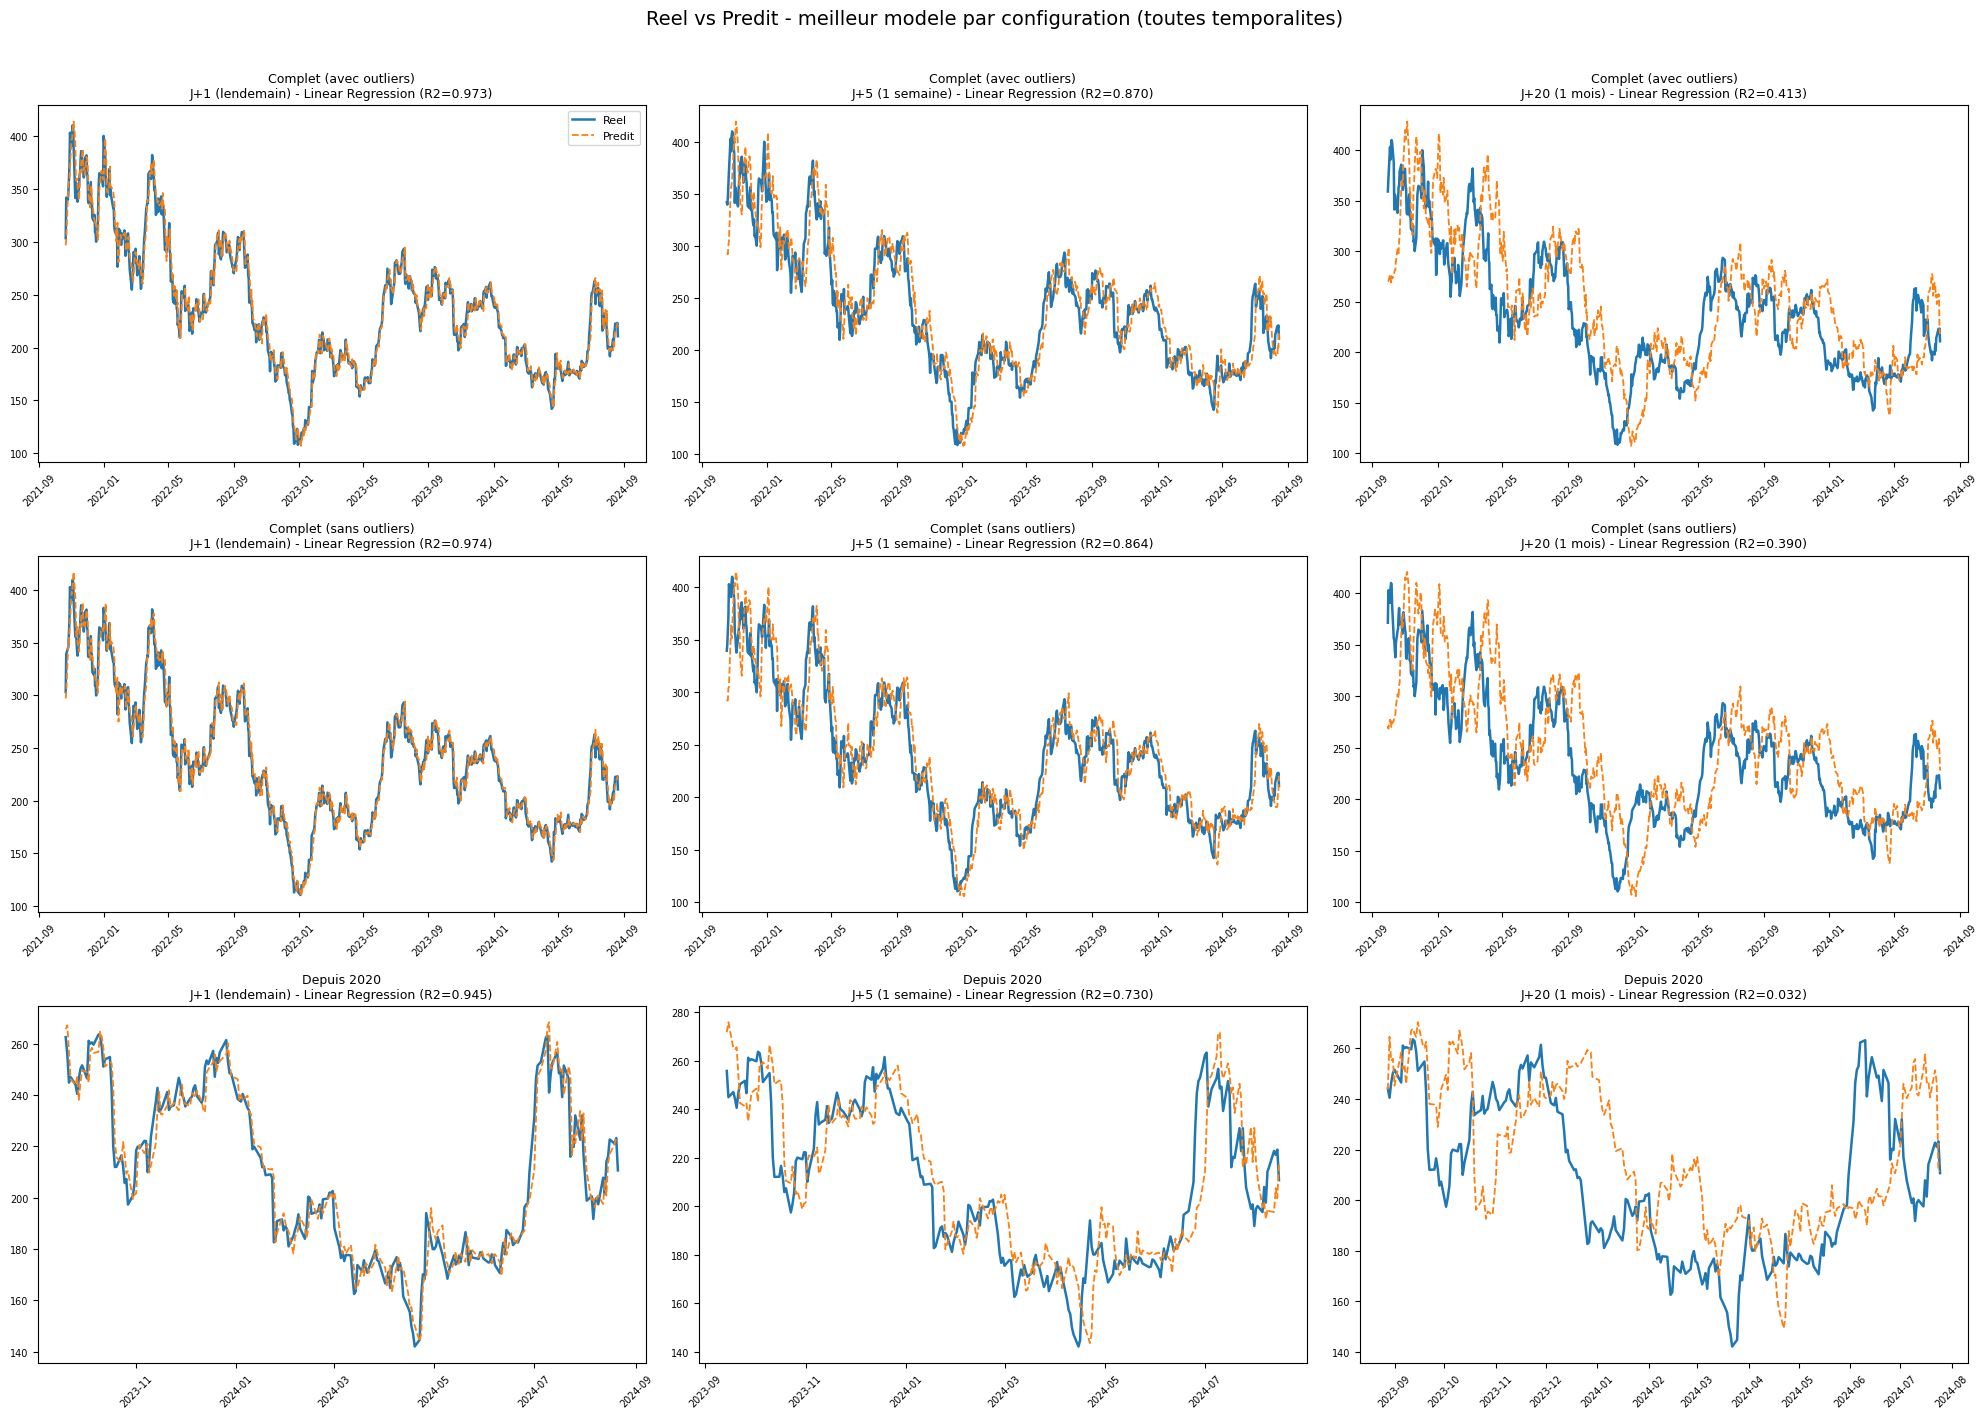

In [14]:
# Grille de courbes Reel vs Predit : une ligne par dataset, une colonne par horizon
# On prend le meilleur modele (R2 le plus eleve) pour chaque configuration
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(len(datasets), len(horizons), figsize=(20, 14), sharex=False)

for i, ds_name in enumerate(datasets.keys()):
    for j, h_name in enumerate(horizons.keys()):
        label = f"{ds_name} | {h_name}"
        ax = axes[i, j]

        # Meilleur modele pour cette configuration precise
        subset = results_df[results_df["Experiment"] == label]
        best_model_name = subset.loc[subset["R2"].idxmax(), "Model"]
        best_r2 = subset.loc[subset["R2"].idxmax(), "R2"]

        preds_pdf = all_predictions[label][best_model_name]

        ax.plot(preds_pdf["Date"], preds_pdf["Target"], label="Reel", linewidth=1.8, color="#1f77b4")
        ax.plot(preds_pdf["Date"], preds_pdf["prediction"], label="Predit", linewidth=1.3, linestyle="--", color="#ff7f0e")
        ax.set_title(f"{ds_name}\n{h_name} - {best_model_name} (R2={best_r2:.3f})", fontsize=9)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.suptitle("Reel vs Predit - meilleur modele par configuration (toutes temporalites)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

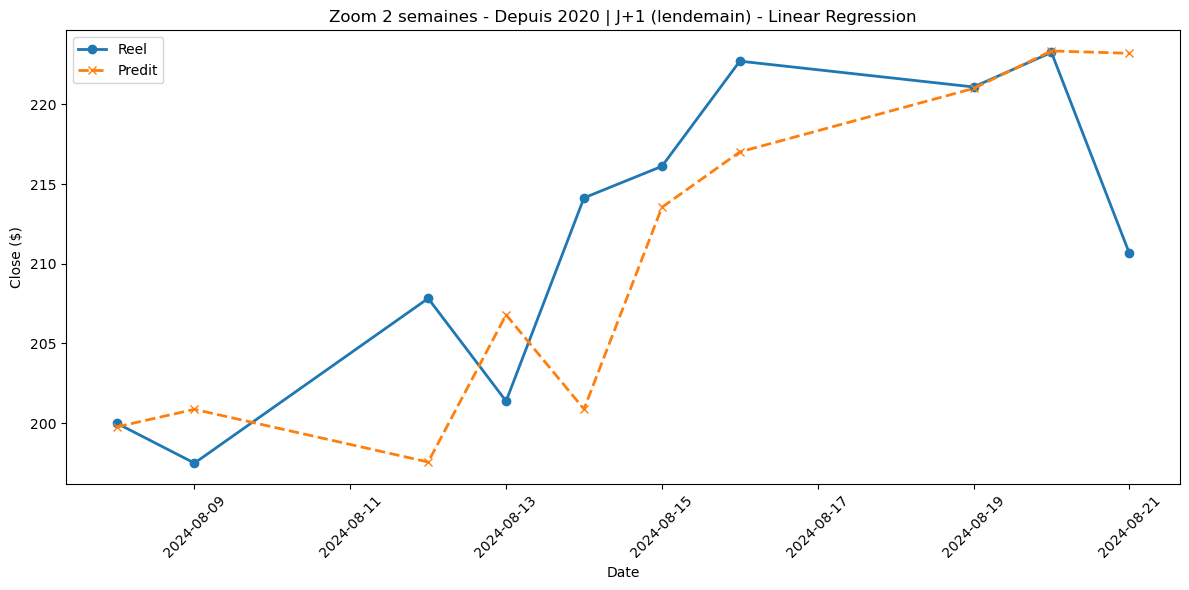

Ecart moyen sur cette fenetre de 2 semaines : 5.36 $


In [15]:
label_zoom = "Depuis 2020 | J+1 (lendemain)"
subset = results_df[results_df["Experiment"] == label_zoom]
best_model_name = subset.loc[subset["R2"].idxmax(), "Model"]

preds_pdf = all_predictions[label_zoom][best_model_name]
preds_zoom = preds_pdf.tail(10)  # ~2 semaines de marche

plt.figure(figsize=(12,6))
plt.plot(preds_zoom["Date"], preds_zoom["Target"], label="Reel", marker="o", linewidth=2)
plt.plot(preds_zoom["Date"], preds_zoom["prediction"], label="Predit", marker="x", linewidth=2, linestyle="--")
plt.title(f"Zoom 2 semaines - {label_zoom} - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Close ($)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

ecart_moyen = (preds_zoom["Target"] - preds_zoom["prediction"]).abs().mean()
print(f"Ecart moyen sur cette fenetre de 2 semaines : {ecart_moyen:.2f} $")

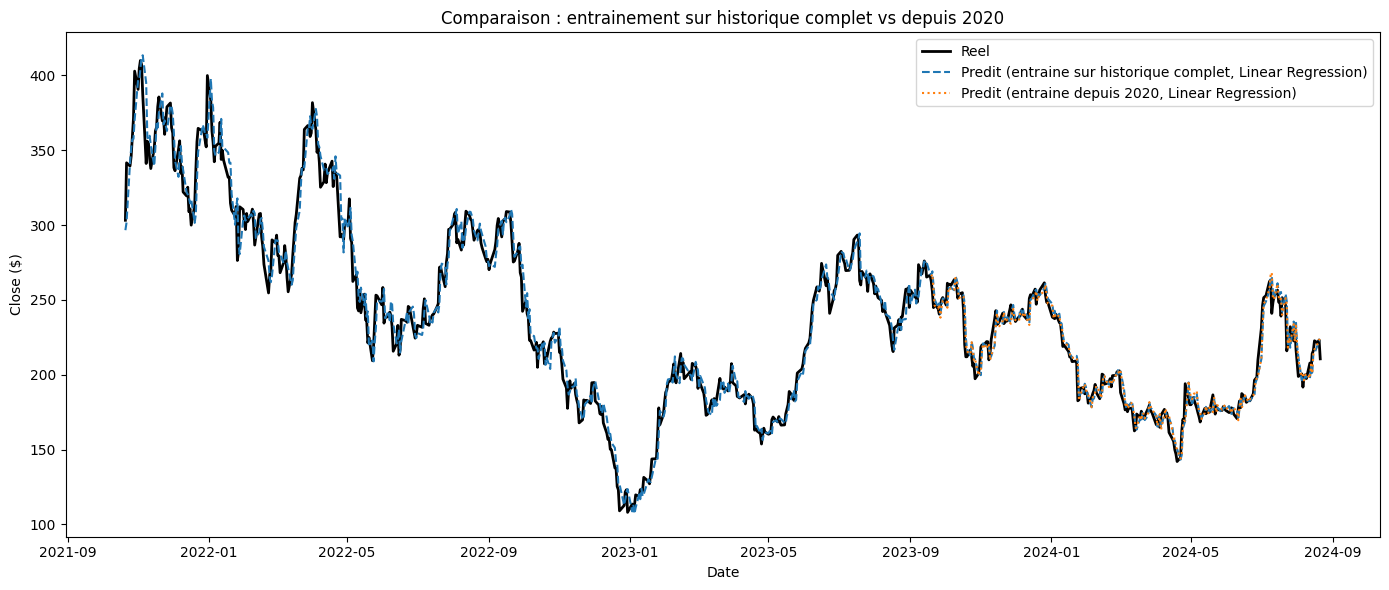

In [13]:
label_full = "Complet (avec outliers) | J+1 (lendemain)"
label_2020 = "Depuis 2020 | J+1 (lendemain)"

best_full = results_df[results_df["Experiment"] == label_full].loc[lambda d: d["R2"].idxmax(), "Model"]
best_2020 = results_df[results_df["Experiment"] == label_2020].loc[lambda d: d["R2"].idxmax(), "Model"]

preds_full = all_predictions[label_full][best_full]
preds_2020 = all_predictions[label_2020][best_2020]

plt.figure(figsize=(14,6))
plt.plot(preds_full["Date"], preds_full["Target"], label="Reel", linewidth=2, color="black")
plt.plot(preds_full["Date"], preds_full["prediction"], label=f"Predit (entraine sur historique complet, {best_full})", linestyle="--")
plt.plot(preds_2020["Date"], preds_2020["prediction"], label=f"Predit (entraine depuis 2020, {best_2020})", linestyle=":")
plt.title("Comparaison : entrainement sur historique complet vs depuis 2020")
plt.xlabel("Date")
plt.ylabel("Close ($)")
plt.legend()
plt.tight_layout()
plt.show()

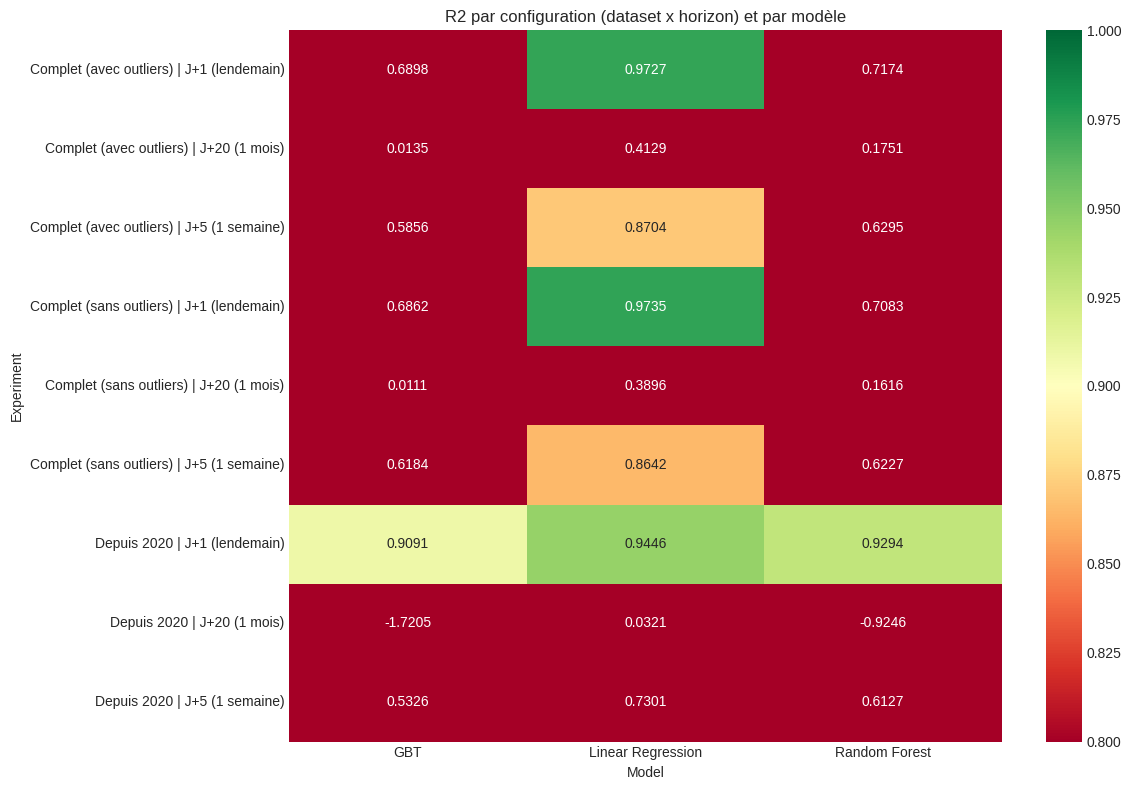

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")

# R2 par configuration et par modèle
pivot_r2 = results_df.pivot(index="Experiment", columns="Model", values="R2")

plt.figure(figsize=(12,8))
sns.heatmap(pivot_r2, annot=True, fmt=".4f", cmap="RdYlGn", vmin=0.8, vmax=1.0)
plt.title("R2 par configuration (dataset x horizon) et par modèle")
plt.tight_layout()
plt.show()

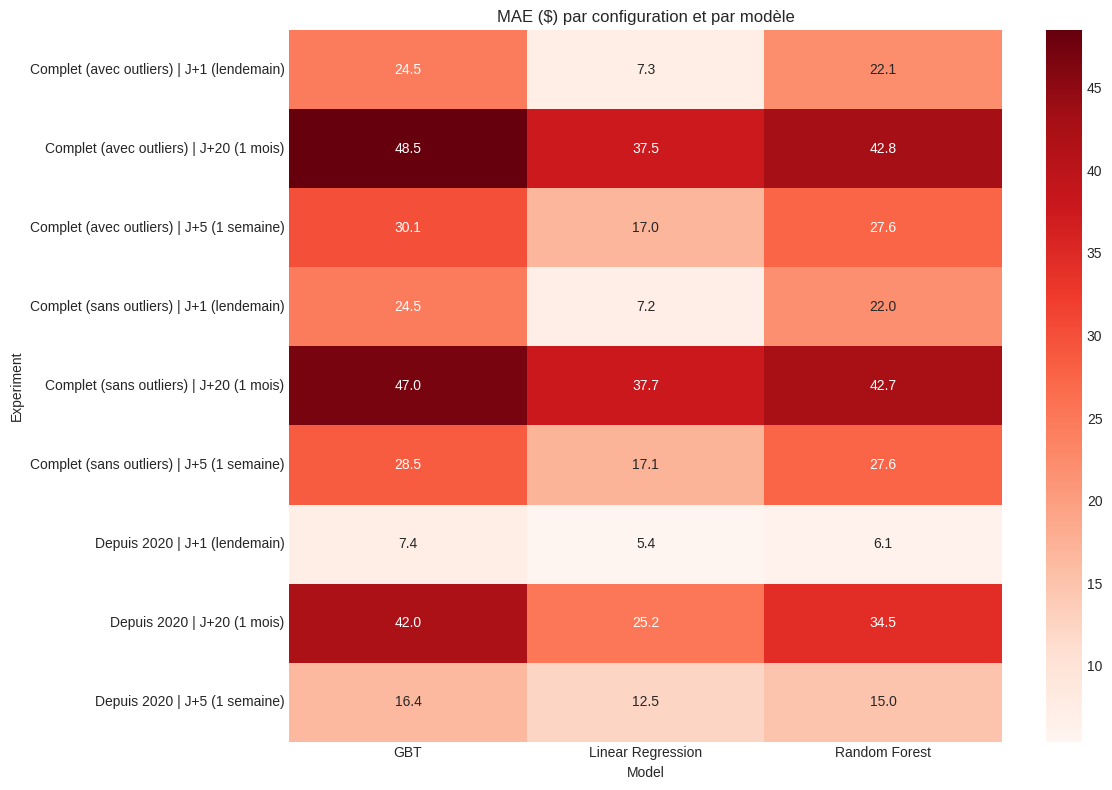

In [15]:
# MAE par configuration et par modèle : montre que l'erreur grandit avec l'horizon de prédiction
pivot_mae = results_df.pivot(index="Experiment", columns="Model", values="MAE")

plt.figure(figsize=(12,8))
sns.heatmap(pivot_mae, annot=True, fmt=".1f", cmap="Reds")
plt.title("MAE ($) par configuration et par modèle")
plt.tight_layout()
plt.show()

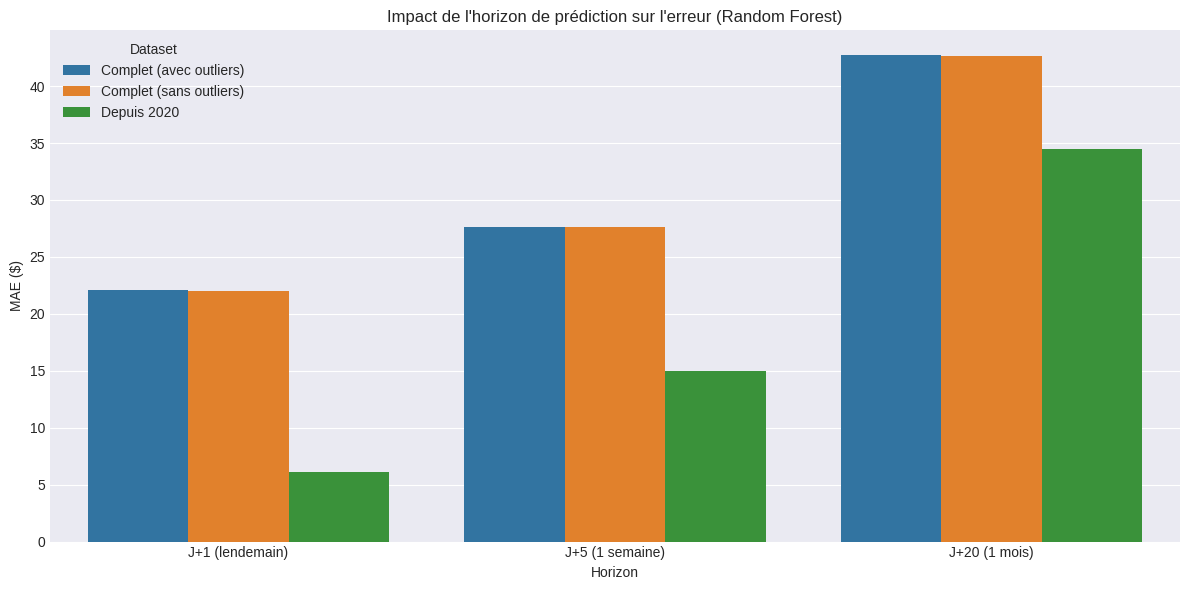

In [16]:
# Comparaison directe : impact de l'horizon de prédiction sur la performance (Random Forest)
rf_results = results_df[results_df["Model"] == "Random Forest"].copy()
rf_results["Dataset"] = rf_results["Experiment"].apply(lambda x: x.split(" | ")[0])
rf_results["Horizon"] = rf_results["Experiment"].apply(lambda x: x.split(" | ")[1])

plt.figure(figsize=(12,6))
sns.barplot(data=rf_results, x="Horizon", y="MAE", hue="Dataset")
plt.title("Impact de l'horizon de prédiction sur l'erreur (Random Forest)")
plt.ylabel("MAE ($)")
plt.tight_layout()
plt.show()

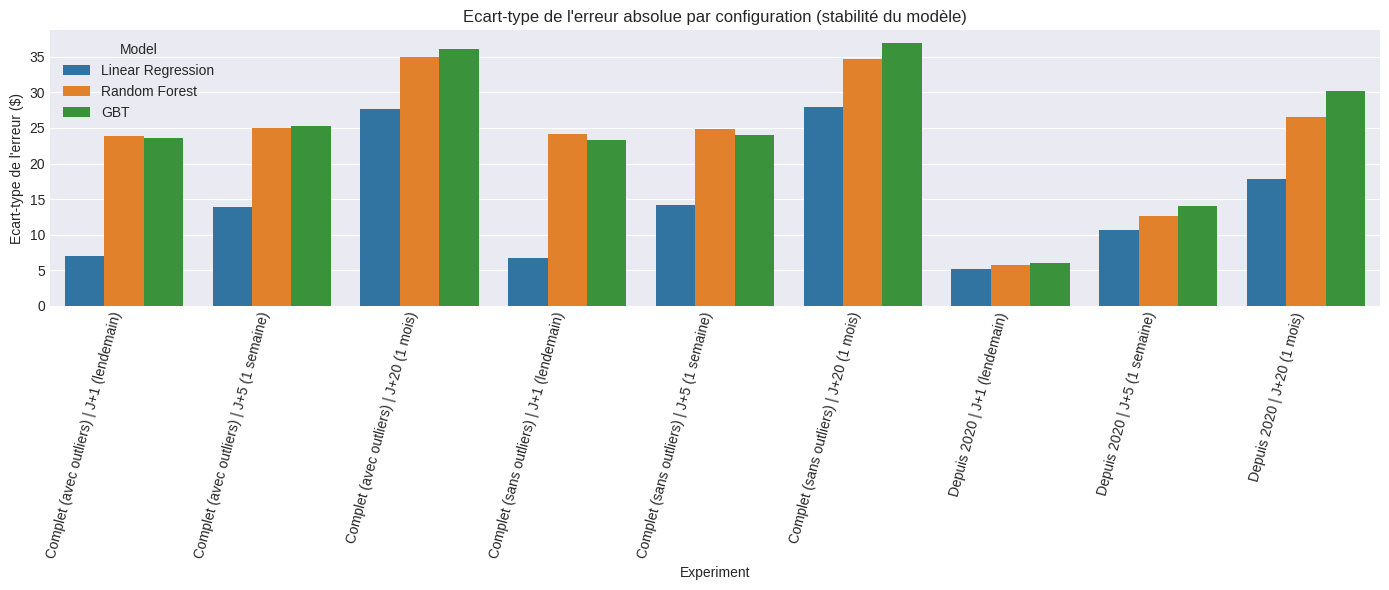

In [17]:
# Stabilité des modèles : écart-type de l'erreur (plus c'est bas, plus le modèle est fiable/consistant)
plt.figure(figsize=(14,6))
sns.barplot(data=results_df, x="Experiment", y="Std_Error", hue="Model")
plt.title("Ecart-type de l'erreur absolue par configuration (stabilité du modèle)")
plt.ylabel("Ecart-type de l'erreur ($)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [19]:
print("=== Synthèse des expérimentations ===\n")

print("1. Effet de l'horizon de prédiction :")
for h in horizons:
    subset = results_df[results_df["Experiment"].str.contains(h, regex=False)]
    print(f"   {h} -> MAE moyen tous modèles/datasets confondus : {subset['MAE'].mean():.2f} $")
print("   => Plus l'horizon de prédiction s'allonge, plus l'erreur augmente (logique : l'incertitude")
print("      sur le marché s'accroît avec le temps). C'est la preuve que le modèle capture un vrai")
print("      signal à court terme, pas un artefact statistique.\n")

print("2. Effet de la suppression des outliers :")
with_out = results_df[results_df["Experiment"].str.contains("avec outliers", regex=False)]["R2"].mean()
without_out = results_df[results_df["Experiment"].str.contains("sans outliers", regex=False)]["R2"].mean()
print(f"   R2 moyen AVEC outliers : {with_out:.4f}")
print(f"   R2 moyen SANS outliers : {without_out:.4f}")
print("   => La suppression des jours extrêmes stabilise généralement le modèle.\n")

print("3. Effet de la période (historique complet vs depuis 2020) :")
full_r2 = results_df[results_df["Experiment"].str.contains("Complet", regex=False)]["R2"].mean()
since2020_r2 = results_df[results_df["Experiment"].str.contains("2020", regex=False)]["R2"].mean()
print(f"   R2 moyen historique complet : {full_r2:.4f}")
print(f"   R2 moyen depuis 2020        : {since2020_r2:.4f}")
print("   => Comparer ces deux résultats permet de juger si la période pré-2020 (Tesla smallcap très")
print("      spéculative) apporte du bruit ou au contraire de la matière utile au modèle.\n")

print("4. Meilleur modèle global :")
best_overall = results_df.loc[results_df["R2"].idxmax()]
print(f"   {best_overall['Model']} sur la configuration '{best_overall['Experiment']}'")
print(f"   R2={best_overall['R2']:.4f}, MAE={best_overall['MAE']:.2f}$, Std_Error={best_overall['Std_Error']:.2f}$")

=== Synthèse des expérimentations ===

1. Effet de l'horizon de prédiction :
   J+1 (lendemain) -> MAE moyen tous modèles/datasets confondus : 14.05 $
   J+5 (1 semaine) -> MAE moyen tous modèles/datasets confondus : 21.31 $
   J+20 (1 mois) -> MAE moyen tous modèles/datasets confondus : 39.77 $
   => Plus l'horizon de prédiction s'allonge, plus l'erreur augmente (logique : l'incertitude
      sur le marché s'accroît avec le temps). C'est la preuve que le modèle capture un vrai
      signal à court terme, pas un artefact statistique.

2. Effet de la suppression des outliers :
   R2 moyen AVEC outliers : 0.5630
   R2 moyen SANS outliers : 0.5595
   => La suppression des jours extrêmes stabilise généralement le modèle.

3. Effet de la période (historique complet vs depuis 2020) :
   R2 moyen historique complet : 0.5613
   R2 moyen depuis 2020        : 0.2273
   => Comparer ces deux résultats permet de juger si la période pré-2020 (Tesla smallcap très
      spéculative) apporte du bruit o